In [62]:
import cv2 
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras import layers, models

In [64]:
# Load the input image  
image_path = r'C:\Users\SHRAVAN\Downloads\leaf_3.png' 
input_image = cv2.imread(image_path)  
input_image = cv2.resize(input_image, (300, 300)) # Resize for UNet model  
input_image = input_image / 255.0 # Normalize

In [5]:
# UNet Model Definition (You can also use a pre-trained model) 
def unet_model(input_shape=(300, 300, 3)):  
    inputs = layers.Input(shape=input_shape)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)  
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)  
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1) 
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)  
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)  
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2) 
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)  
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3) 
# Decoder: Upsampling 
    up1 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv3)  
    up1 = layers.concatenate([up1, conv2], axis=-1) 
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(up1)  
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)  
    up2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv4)  
    up2 = layers.concatenate([up2, conv1], axis=-1)  
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up2)  
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5) 
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5) # Sigmoid for 
    model = models.Model(inputs=[inputs], outputs=[outputs])  
    return model

In [7]:
# Initialize and compile the UNet model  
model = unet_model() 
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  

In [9]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [11]:
input_image_batch = np.expand_dims(input_image, axis=0) 

In [13]:
segmentation_output = model.predict(input_image_batch)
segmentation_output = (segmentation_output > 0.5).astype(np.uint8)  
segmentation_output = np.squeeze(segmentation_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [15]:
cv2.imwrite(r'C:\Users\SHRAVAN\Desktop\segmented_output.png', segmentation_output * 255)  
cv2.waitKey(0) 
cv2.destroyAllWindows()# Save the segmented image  

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 300, 300, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 300, 300, 64)      │           1,792 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 300, 300, 64)      │          36,928 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 150, 150, 64)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 150, 150, 128)     │          73,856 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 150, 150, 128)     │         147,584 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 75, 75, 128)       │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 75, 75, 256)       │         295,168 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 75, 75, 256)       │         590,080 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 150, 150, 128)     │         131,200 │ conv2d_5[0][0]             │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 150, 150, 256)     │               0 │ conv2d_transpose[0][0],    │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 150, 150, 128)     │         295,040 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 150, 150, 128)     │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_1            │ (None, 300, 300, 64)      │          32,832 │ conv2d_7[0][0]             │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 300, 300, 128)     │               0 │ conv2d_transpose_1[0][0],  │
│                               │                           │               

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

In [21]:
if os.path.exists(r'C:\Users\SHRAVAN\Downloads\leaf_3.png'):
    print("Image found ✅")
else:
    print("Image NOT found ❌")


Image found ✅


In [23]:
img = image.load_img(r'C:\Users\SHRAVAN\Downloads\leaf_3.png', target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Image processed successfully")


Image processed successfully


In [25]:
prediction = model.predict(img_array)[0]

# Assuming index 0 = Healthy, rest = Disease
disease_percentage = np.max(prediction[1:]) * 100

print(f"Disease Percentage: {disease_percentage:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Disease Percentage: 53.08%


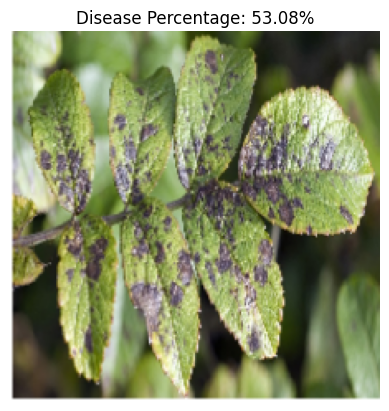

In [27]:
plt.imshow(img)
plt.axis("off")
plt.title(f"Disease Percentage: {disease_percentage:.2f}%")
plt.show()


In [29]:
if disease_percentage < 30:
    level = "Low Disease"
elif disease_percentage < 50:
    level = "Medium Disease"
else:
    level = "High Disease"

print("Disease Level:", level)


Disease Level: High Disease


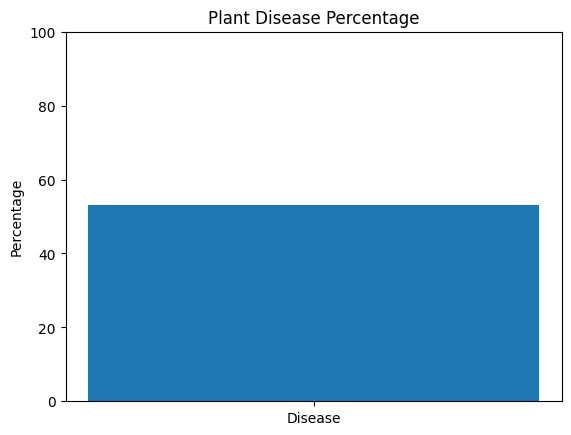

In [31]:
plt.bar(["Disease"], [disease_percentage])
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title("Plant Disease Percentage")
plt.show()


In [33]:
with open("plant_result.txt", "w") as f:
    f.write(f"Disease Percentage: {disease_percentage:.2f}%\n")
    f.write(f"Disease Level: {level}")

print("Result saved to plant_result.txt")


Result saved to plant_result.txt


In [35]:
class_names = [
    "Healthy",
    "Leaf Blight",
    "Leaf Spot",
    "Powdery Mildew"
]


In [37]:
remedies = {
    "Healthy": "No treatment needed. Maintain proper watering and sunlight.",
    
    "Leaf Blight": 
    "• Remove infected leaves\n"
    "• Use copper-based fungicide\n"
    "• Avoid overhead watering",
    
    "Leaf Spot": 
    "• Remove affected leaves\n"
    "• Apply neem oil or fungicide\n"
    "• Improve air circulation",
    
    "Powdery Mildew": 
    "• Spray sulfur or neem oil\n"
    "• Avoid excess moisture\n"
    "• Ensure good sunlight"
}


In [39]:
print("Model output shape:", model.output_shape)
print("Number of classes predicted by model:", model.output_shape[-1])


Model output shape: (None, 300, 300, 1)
Number of classes predicted by model: 1


In [41]:
prediction = model.predict(img_array)[0]

predicted_index = np.argmax(prediction)

disease_percentage = np.max(prediction[1:]) * 100


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [43]:
# Remedy library for plant diseases
remedy_dict = {
    "leaf_blight": {
        "name": "Leaf Blight",
        "remedy": [
            "Remove infected leaves immediately.",
            "Apply copper-based fungicides.",
            "Avoid overhead watering.",
            "Improve air circulation around plants."
        ]
    },
    "leaf_spot": {
        "name": "Leaf Spot",
        "remedy": [
            "Spray Neem oil weekly.",
            "Do not wet leaves while watering.",
            "Remove infected leaves to stop spread.",
            "Use fungicide like Mancozeb if severe."
        ]
    },
    "powdery_mildew": {
        "name": "Powdery Mildew",
        "remedy": [
            "Spray baking soda solution (1 tsp baking soda + 1L water).",
            "Avoid humidity and improve sunlight.",
            "Use Sulfur fungicides for high infection."
        ]
    },
    "rust": {
        "name": "Rust Disease",
        "remedy": [
            "Remove and destroy infected leaves.",
            "Apply sulfur dust or copper sprays.",
            "Avoid wetting foliage when watering."
        ]
    },
    "healthy": {
        "name": "Healthy",
        "remedy": [
            "No treatment required. Keep monitoring the plant."
        ]
    }
}


In [45]:
predicted_disease = "leaf_blight"

In [47]:
# Show remedy for predicted disease

if predicted_disease in remedy_dict:
    print("Disease Detected:", remedy_dict[predicted_disease]["name"])
    print("\nRecommended Remedies:\n")
    for r in remedy_dict[predicted_disease]["remedy"]:
        print("✔", r)
else:
    print("Disease not found in remedy library!")


Disease Detected: Leaf Blight

Recommended Remedies:

✔ Remove infected leaves immediately.
✔ Apply copper-based fungicides.
✔ Avoid overhead watering.
✔ Improve air circulation around plants.


In [49]:
severity_level = "High"   # or "Medium" or "Low"
# Severity-based extra advice
if severity_level == "High":
    print("\nSeverity Level:", severity_level)
    print("⚠ Advanced Treatment Suggested:")
    print("→ Use fungicide treatment and isolate plant if possible.\n")

elif severity_level == "Medium":
    print("\nSeverity Level:", severity_level)
    print("→ Use organic spray and remove infected areas.\n")

else:
    print("\nSeverity Level:", severity_level)
    print("→ Basic monitoring and preventive care.\n")


Severity Level: High
⚠ Advanced Treatment Suggested:
→ Use fungicide treatment and isolate plant if possible.



In [51]:
# Organic remedy library for plant diseases

organic_remedy = {
    "leaf_spot": {
        "name": "Leaf Spot (Fungal)",
        "remedies": [
            "Spray Neem oil (5 ml per 1 liter of water) weekly.",
            "Do not water leaves directly; water only at soil level.",
            "Improve sunlight and airflow around plant.",
            "Remove infected leaves to stop spreading."
        ],
        "extra": "Mulching and compost tea can boost plant immunity."
    },
    "leaf_blight": {
        "name": "Leaf Blight",
        "remedies": [
            "Apply Garlic spray (10g crushed garlic + 1 liter water).",
            "Use Neem oil weekly on foliage.",
            "Maintain proper spacing between plants.",
            "Remove severely infected parts immediately."
        ],
        "extra": "Use Trichoderma in soil for biological control."
    },
    "powdery_mildew": {
        "name": "Powdery Mildew",
        "remedies": [
            "Spray baking soda solution (1 tsp baking soda + 1L water).",
            "Increase sunlight exposure.",
            "Avoid humid & shaded conditions."
        ],
        "extra": "Milk spray (1:10 milk to water) also works as antifungal."
    },
    "healthy": {
        "name": "Healthy",
        "remedies": [
            "No treatment needed.",
            "Maintain regular care and watering."
        ],
        "extra": "Keep monitoring to prevent future infection."
    }
}


In [53]:
predicted_disease = "leaf_spot"

# Display organic remedy
if predicted_disease in organic_remedy:
    data = organic_remedy[predicted_disease]
    print("Disease Detected:", data["name"])
    print("\nOrganic Remedies:\n")
    for r in data["remedies"]:
        print("✔", r)
    print("\nAdditional Advice:", data["extra"])
else:
    print("No remedy found for detected disease.")


Disease Detected: Leaf Spot (Fungal)

Organic Remedies:

✔ Spray Neem oil (5 ml per 1 liter of water) weekly.
✔ Do not water leaves directly; water only at soil level.
✔ Improve sunlight and airflow around plant.
✔ Remove infected leaves to stop spreading.

Additional Advice: Mulching and compost tea can boost plant immunity.


In [55]:
# Disease knowledge database: how, why, time of occurrence

disease_info = {
    "leaf_spot": {
        "how": [
            "Fungal spores land on leaf surface",
            "Spores germinate under moist conditions",
            "Infection spreads to healthy tissues"
        ],
        "why": [
            "High humidity around the plant",
            "Water droplets remain on leaves",
            "Poor air circulation",
            "Warm and wet climate"
        ],
        "time": [
            "Occurs mostly during rainy seasons",
            "More common in early monsoon",
            "Can increase after frequent watering"
        ]
    },

    "powdery_mildew": {
        "how": [
            "Fungal spores spread through air",
            "Spores germinate on dry leaf surfaces",
            "White powder-like layer forms"
        ],
        "why": [
            "Low sunlight exposure",
            "High humidity and overcrowded plants",
            "Poor ventilation"
        ],
        "time": [
            "Common during winter season",
            "Occurs when days are warm and nights are cool",
            "Develops during low sunlight periods"
        ]
    },

    "leaf_blight": {
        "how": [
            "Pathogen enters through leaf stomata",
            "Tissue collapses and turns brown",
            "Spreads through rain splash"
        ],
        "why": [
            "Fungal infection from soil or residues",
            "High temperature + wet environment",
            "Overhead irrigation"
        ],
        "time": [
            "Common in late rainy season",
            "Appears after continuous rainfall",
            "Spreads faster during warm humid days"
        ]
    },

    "rust": {
        "how": [
            "Spores settle on leaf surface",
            "Penetrate plant cells",
            "Form orange/brown rust-like patches"
        ],
        "why": [
            "Cool nights and warm days",
            "Water splashed onto leaves",
            "Windborne fungal spores"
        ],
        "time": [
            "Often occurs during spring",
            "During temperature fluctuations",
            "After repeated leaf wetting"
        ]
    },

    "healthy": {
        "how": ["No infection present"],
        "why": ["No disease-causing conditions"],
        "time": ["No disease timeline"]
    }
}


In [57]:
predicted_disease = "leaf_spot"

In [59]:
if predicted_disease in disease_info: print(f"\nDisease: {predicted_disease.replace('_',' ').title()}\n")

print("HOW the disease occurs:\n")
for step in disease_info[predicted_disease]["how"]:
    print("•", step)

print("\nWHY the disease occurs:\n")
for reason in disease_info[predicted_disease]["why"]:
    print("•", reason)

print("\nWHEN (time) it occurs:\n")
for timing in disease_info[predicted_disease]["time"]:
    print("•", timing)

else:
    print("Disease information not available.")


Disease: Leaf Spot

HOW the disease occurs:

• Fungal spores land on leaf surface
• Spores germinate under moist conditions
• Infection spreads to healthy tissues

WHY the disease occurs:

• High humidity around the plant
• Water droplets remain on leaves
• Poor air circulation
• Warm and wet climate

WHEN (time) it occurs:

• Occurs mostly during rainy seasons
• More common in early monsoon
• Can increase after frequent watering
Disease information not available.


In [1]:
import os; print(os.getcwd())

C:\Users\SHRAVAN\Major Project
